In [1]:
## Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load the dataset
data = pd.read_csv("C:/Users/User/Desktop/Python Data Analysis/Category Values.csv")

In [3]:
## print("First rows of data:")
print(data.head())

   OrderID  OrderDate CustomerID  Gender Department  StaffSalary  \
0     1001   1/5/2025       C001  Female      Sales        500.0   
1     1002   1/7/2025       C002    Male    Support        400.0   
2     1003  1/10/2025       C003  Female      Sales          NaN   
3     1004  1/12/2025       C004    Male  Marketing        600.0   
4     1005  1/15/2025       C005  Female      Sales        500.0   

  ProductCategory  Quantity  UnitPrice  Revenue  
0     Electronics         2        250      500  
1         Fashion         3         50      150  
2     Electronics         1        300      300  
3       Groceries        10         20      200  
4         Fashion         2         80      160  


In [4]:
## Handle missing values
# Fill missing StaffSalary with the mean

data["StaffSalary"] = data["StaffSalary"].fillna(data["StaffSalary"].mean())

In [5]:
##  Convert OrderDate to datetime and extract Year, Month

data["OrderDate"] = pd.to_datetime(data["OrderDate"])
data["Year"] = data["OrderDate"].dt.year
data["Month"] = data["OrderDate"].dt.month

print(data[["OrderDate","Year","Month"]].head())


   OrderDate  Year  Month
0 2025-01-05  2025      1
1 2025-01-07  2025      1
2 2025-01-10  2025      1
3 2025-01-12  2025      1
4 2025-01-15  2025      1


In [6]:
##  One-Hot Encoding for categorical variables

data_encoded = pd.get_dummies(data, columns=["Gender","Department","ProductCategory"])
print("Data after encoding:")
print(data_encoded.head())

Data after encoding:
   OrderID  OrderDate CustomerID  StaffSalary  Quantity  UnitPrice  Revenue  \
0     1001 2025-01-05       C001   500.000000         2        250      500   
1     1002 2025-01-07       C002   400.000000         3         50      150   
2     1003 2025-01-10       C003   488.888889         1        300      300   
3     1004 2025-01-12       C004   600.000000        10         20      200   
4     1005 2025-01-15       C005   500.000000         2         80      160   

   Year  Month  Gender_Female  Gender_Male  Department_Marketing  \
0  2025      1           True        False                 False   
1  2025      1          False         True                 False   
2  2025      1           True        False                 False   
3  2025      1          False         True                  True   
4  2025      1           True        False                 False   

   Department_Sales  Department_Support  ProductCategory_Electronics  \
0              True    

In [7]:
data_encoded = pd.get_dummies(data, columns=["Gender","Department","ProductCategory"], dtype=int)
print(data_encoded.head())



   OrderID  OrderDate CustomerID  StaffSalary  Quantity  UnitPrice  Revenue  \
0     1001 2025-01-05       C001   500.000000         2        250      500   
1     1002 2025-01-07       C002   400.000000         3         50      150   
2     1003 2025-01-10       C003   488.888889         1        300      300   
3     1004 2025-01-12       C004   600.000000        10         20      200   
4     1005 2025-01-15       C005   500.000000         2         80      160   

   Year  Month  Gender_Female  Gender_Male  Department_Marketing  \
0  2025      1              1            0                     0   
1  2025      1              0            1                     0   
2  2025      1              1            0                     0   
3  2025      1              0            1                     1   
4  2025      1              1            0                     0   

   Department_Sales  Department_Support  ProductCategory_Electronics  \
0                 1                   0     

In [8]:
## to see the transformed rows
print(data_encoded.filter(regex="Gender|Department|ProductCategory").head())


   Gender_Female  Gender_Male  Department_Marketing  Department_Sales  \
0              1            0                     0                 1   
1              0            1                     0                 0   
2              1            0                     0                 1   
3              0            1                     1                 0   
4              1            0                     0                 1   

   Department_Support  ProductCategory_Electronics  ProductCategory_Fashion  \
0                   0                            1                        0   
1                   1                            0                        1   
2                   0                            1                        0   
3                   0                            0                        0   
4                   0                            0                        1   

   ProductCategory_Groceries  
0                          0  
1                       

In [9]:
## to see all new dummy columns
print(data_encoded.columns)


Index(['OrderID', 'OrderDate', 'CustomerID', 'StaffSalary', 'Quantity',
       'UnitPrice', 'Revenue', 'Year', 'Month', 'Gender_Female', 'Gender_Male',
       'Department_Marketing', 'Department_Sales', 'Department_Support',
       'ProductCategory_Electronics', 'ProductCategory_Fashion',
       'ProductCategory_Groceries'],
      dtype='object')


In [10]:
## Count how many dummy columns were created
print("Number of columns after encoding:", len(data_encoded.columns))


Number of columns after encoding: 17


In [11]:
##  Group by Department to show total Revenue

dept_revenue = data.groupby("Department")["Revenue"].sum()
print("Revenue by Department:")
print(dept_revenue)

Revenue by Department:
Department
Marketing     300
Sales        1760
Support      1370
Name: Revenue, dtype: int64


In [12]:
##  Group by Month to show total Revenue

monthly_revenue = data.groupby("Month")["Revenue"].sum()
print("Revenue by Month:")
print(monthly_revenue)

Revenue by Month:
Month
1    2930
2     500
Name: Revenue, dtype: int64


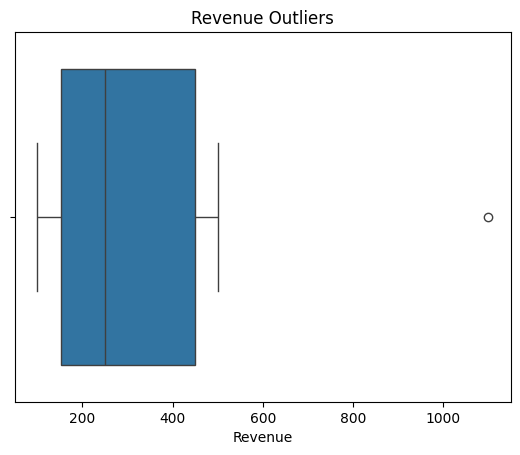

In [13]:
## Outlier detection with boxplot

sns.boxplot(x=data["Revenue"])
plt.title("Revenue Outliers")
plt.show()

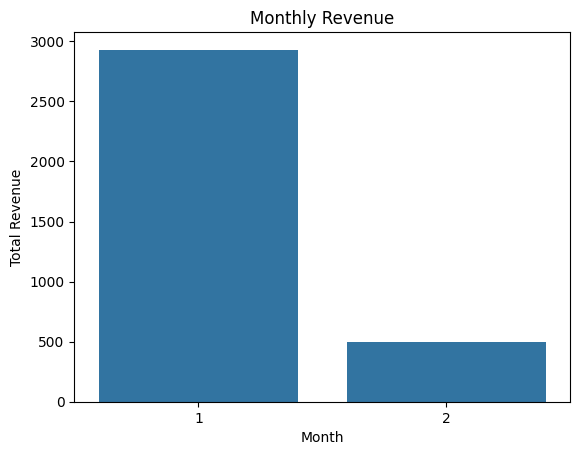

In [14]:
## Visualization of monthly revenue
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_13208\734017404.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette="viridis")


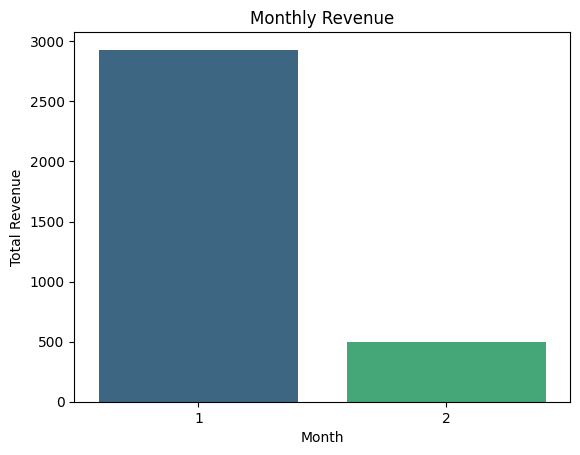

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Monthly revenue bar chart
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette="viridis")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()


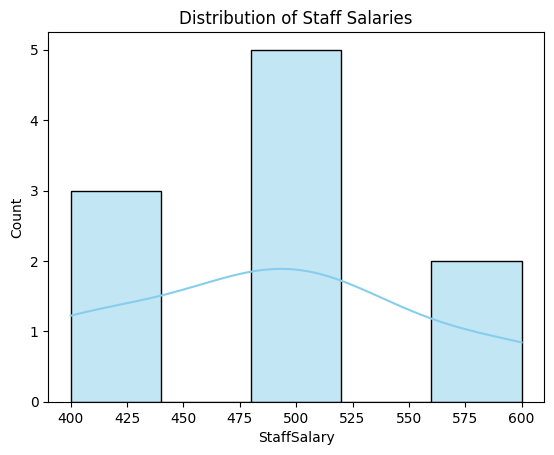

In [16]:
sns.histplot(data["StaffSalary"], bins=5, kde=True, color="skyblue")
plt.title("Distribution of Staff Salaries")
plt.show()


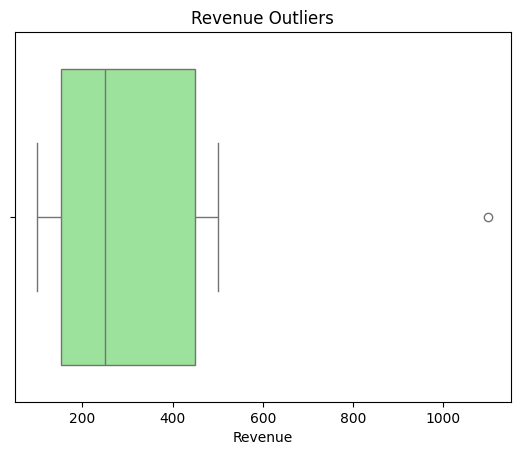

In [17]:
sns.boxplot(x=data["Revenue"], color="lightgreen")
plt.title("Revenue Outliers")
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_13208\2118965161.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data["Department"], y=data["Revenue"], palette=custom_colors)


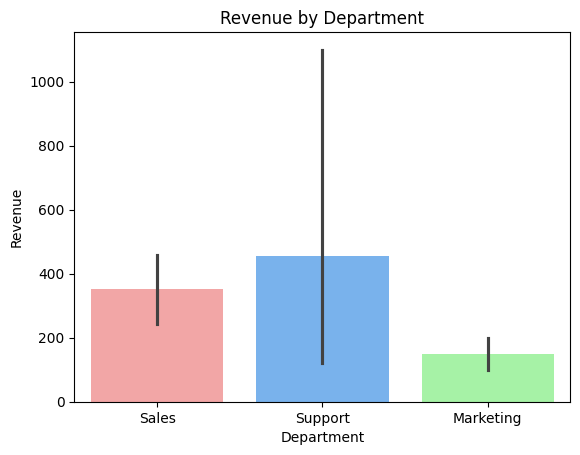

In [18]:
custom_colors = ["#FF9999", "#66B2FF", "#99FF99"]
sns.barplot(x=data["Department"], y=data["Revenue"], palette=custom_colors)
plt.title("Revenue by Department")
plt.show()


ascending=False → tells pandas to sort in descending order (highest to lowest).

If you used ascending=True (the default), it would sort in ascending order (lowest to highest).

Business Use
Identify best customers.

Reward them with loyalty programs.

Understand who drives most of the sales.

In [ ]:
## Sorting & Ranking
# Find the top 5 customers by revenue and the lowest 5 by revenue.
top_customers = data.sort_values("Revenue", ascending=False).head(5)
bottom_customers = data.sort_values("Revenue").head(5)
print(top_customers)
print(bottom_customers)


   OrderID  OrderDate CustomerID  Gender Department  StaffSalary  \
5     1006 2025-01-20       C006    Male    Support   400.000000   
0     1001 2025-01-05       C001  Female      Sales   500.000000   
9     1010 2025-02-01       C010    Male      Sales   500.000000   
7     1008 2025-01-25       C008    Male      Sales   500.000000   
2     1003 2025-01-10       C003  Female      Sales   488.888889   

  ProductCategory  Quantity  UnitPrice  Revenue  Year  Month  
5     Electronics         5        220     1100  2025      1  
0     Electronics         2        250      500  2025      1  
9     Electronics         1        500      500  2025      2  
7       Groceries        20         15      300  2025      1  
2     Electronics         1        300      300  2025      1  
   OrderID  OrderDate CustomerID  Gender Department  StaffSalary  \
6     1007 2025-01-22       C007  Female  Marketing        600.0   
8     1009 2025-01-28       C009  Female    Support        400.0   
1     100

values="Revenue" → we want to analyze revenue.

index="Department" → rows will be grouped by department.

columns="Gender" → columns will split by gender.

aggfunc="sum" → we calculate the total revenue for each combination.

Business Use
Compare male vs. female customers across departments.

Spot trends (e.g., “Females spend more in Sales, but Males spend more in Marketing”).

Helps managers tailor strategies by department and customer segment.



In [20]:
## Pivot Table 
# Show total revenue by Department and Gender.

pivot = data.pivot_table(values="Revenue", index="Department", columns="Gender", aggfunc="sum")
print(pivot)

Gender      Female  Male
Department              
Marketing      100   200
Sales          960   800
Support        120  1250


In [21]:
## Multi‑Level Grouping
# Group by Department + ProductCategory to see combined revenue.

grouped = data.groupby(["Department","ProductCategory"])["Revenue"].sum()
print(grouped)

Department  ProductCategory
Marketing   Fashion             100
            Groceries           200
Sales       Electronics        1300
            Fashion             160
            Groceries           300
Support     Electronics        1100
            Fashion             270
Name: Revenue, dtype: int64


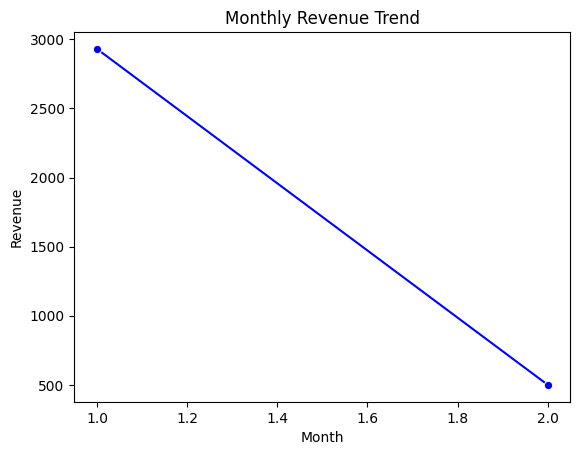

In [27]:
# 2. Line chart: Monthly Revenue trend
monthly_revenue = data.groupby("Month")["Revenue"].sum().reset_index()
sns.lineplot(x="Month", y="Revenue", data=monthly_revenue, marker="o", color="blue")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_13208\4229587854.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Department", y="Revenue", data=dept_revenue, palette="viridis")


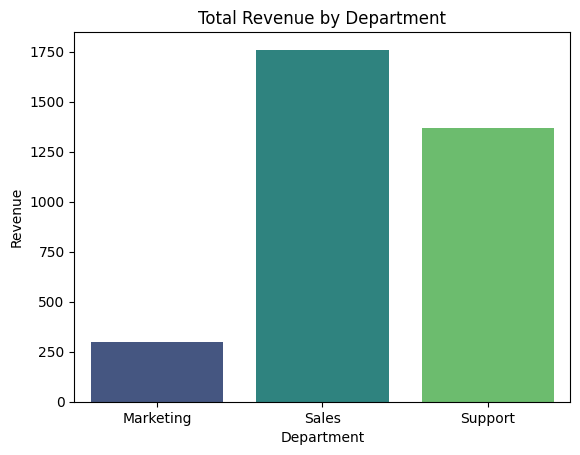

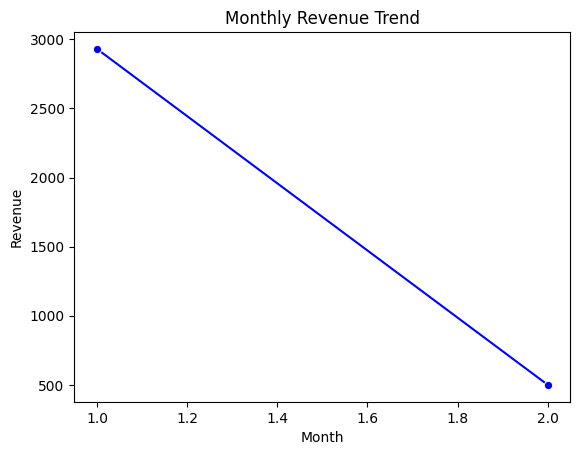

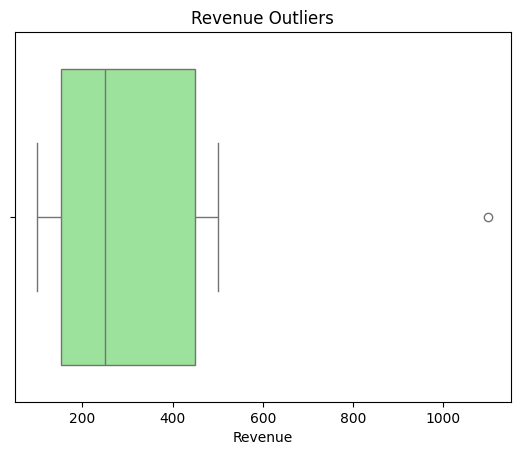

In [25]:
### Dashboard Mini‑Project Code
## Bar chart (Revenue by Department): Shows which department contributes most to revenue.

## Line chart (Monthly Revenue Trend): Reveals seasonal or monthly sales patterns.

## Boxplot (Revenue Outliers): Highlights unusual sales values that may need investigation.

# 1. Bar chart: Revenue by Department
dept_revenue = data.groupby("Department")["Revenue"].sum().reset_index()
sns.barplot(x="Department", y="Revenue", data=dept_revenue, palette="viridis")
plt.title("Total Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.show()

# 2. Line chart: Monthly Revenue trend
monthly_revenue = data.groupby("Month")["Revenue"].sum().reset_index()
sns.lineplot(x="Month", y="Revenue", data=monthly_revenue, marker="o", color="blue")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

# 3. Boxplot: Revenue outliers
sns.boxplot(x=data["Revenue"], color="lightgreen")
plt.title("Revenue Outliers")
plt.xlabel("Revenue")
plt.show()
